# Speech Emotion Recognition on IEMOCAP Dataset
## 10-Fold Speaker-Independent Cross-Validation

This notebook uses pre-processed IEMOCAP CSV files for:
- 4 emotion classes: neutral, sad, angry, happy (happy+excited merged)
- 10-fold speaker-independent cross-validation
- Following paper recommendations (Antoniou et al., 2023)

In [2]:
# =============================================
# IMPORTS AND CONFIGURATION
# =============================================

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import GradScaler, autocast

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.8.0


In [3]:
# =============================================
# CONFIGURATION
# =============================================

# Data paths - UPDATE THESE
# ===== UPDATE THESE PATHS =====
CSV_FILE = "iemocap_4class.csv"        # Your CSV file name
AUDIO_ROOT = "iemocap_env"             # Where your audio files are
OUTPUT_DIR = "iemocap_results"         # Where to save results

# Audio processing
SAMPLE_RATE   = 16000
N_FFT         = 2048
HOP_LENGTH    = 512
N_MFCC        = 40
N_CHROMA      = 12
SEGMENT_SEC   = 3
SEGMENT_LEN   = SEGMENT_SEC * SAMPLE_RATE

# Training parameters
BATCH_SIZE    = 32
EPOCHS        = 50
PATIENCE      = 10
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 1e-4
NUM_WORKERS   = 0  # Set to 0 if you encounter multiprocessing issues

# Output directory
OUTPUT_DIR = "iemocap_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded successfully!")

Configuration loaded successfully!


In [8]:
# =============================================
# LOAD PRE-PROCESSED DATA FROM CSV
# =============================================

print(f"Loading data from {CSV_FILE}...")
df = pd.read_csv(CSV_FILE)

print(f"\nDataset Info:")
print(f"Total samples: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

# Check emotion distribution
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts().sort_index())

# Extract file paths, labels, and speakers
# Adjust column names based on your CSV structure
# Extract file paths, labels, and speakers
# YOUR CSV HAS 'audio_path' COLUMN!
if 'audio_path' in df.columns:
    file_paths = df['audio_path'].tolist()
    print(f"\n✓ Using 'audio_path' column from CSV")
elif 'path' in df.columns:
    file_paths = df['path'].tolist()
elif 'file_path' in df.columns:
    file_paths = df['file_path'].tolist()
elif 'wav_file' in df.columns:
    file_paths = df['wav_file'].tolist()
else:
    print("\n❌ ERROR: No audio path column found in CSV!")
    print(f"Available columns: {df.columns.tolist()}")
    raise ValueError("Cannot find audio file paths in CSV")

labels = df['emotion'].tolist()

# Extract speaker information
if 'speaker' in df.columns:
    speakers = df['speaker'].tolist()
else:
    # Extract speaker from filename (format: Ses01F_xxx_xxx.wav)
    speakers = []
    for path in file_paths:
        filename = os.path.basename(path)
        # Extract speaker ID from utterance (e.g., Ses01F_impro01_F000)
        speaker_id = filename.split('_')[0] if '_' in filename else 'Unknown'
        speakers.append(speaker_id)
    print("\nExtracted speaker IDs from filenames")

print(f"\nUnique speakers: {sorted(set(speakers))}")
print(f"Number of speakers: {len(set(speakers))}")

# Convert to numpy arrays for easier indexing
file_paths = np.array(file_paths)
labels_array = np.array(labels)
speakers_array = np.array(speakers)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels_array)
print(f"\nEncoded classes: {le.classes_}")
print(f"Class distribution: {np.bincount(y)}")

Loading data from iemocap_4class.csv...

Dataset Info:
Total samples: 5357

Columns: ['utterance_id', 'session', 'dialog', 'emotion', 'valence', 'activation', 'dominance', 'start_time', 'end_time', 'duration', 'speaker_id', 'speaker_gender', 'turn_speaker', 'interaction_type', 'audio_path', 'audio_exists', 'label', 'speaker']

First few rows:
          utterance_id  session          dialog emotion  valence  activation  \
0  Ses01F_impro01_F000        1  Ses01F_impro01     neu      2.5         2.5   
1  Ses01F_impro01_F001        1  Ses01F_impro01     neu      2.5         2.5   
2  Ses01F_impro01_F002        1  Ses01F_impro01     neu      2.5         2.5   
3  Ses01F_impro01_F005        1  Ses01F_impro01     neu      2.5         3.5   
4  Ses01F_impro01_F012        1  Ses01F_impro01     ang      2.0         3.5   

   dominance  start_time  end_time  duration speaker_id speaker_gender  \
0        2.5      6.2901    8.2357    1.9456     Ses01F              F   
1        2.5     10.0100  

In [9]:
# DIAGNOSTIC CODE - Run this in a notebook cell
import pandas as pd
import os

CSV_FILE = "iemocap_4class.csv"
AUDIO_ROOT = "iemocap_env"

print("=" * 70)
print("CHECKING FILE PATHS")
print("=" * 70)

# Load CSV
df = pd.read_csv(CSV_FILE)
print(f"\n✓ CSV loaded: {len(df)} rows")
print(f"Columns: {df.columns.tolist()}\n")

# Find path column
path_col = 'path' if 'path' in df.columns else df.columns[0]
print(f"Using column: '{path_col}'")

# Show sample paths
print(f"\nSample paths from CSV:")
for i, path in enumerate(df[path_col].head(5), 1):
    print(f"  {i}. {path}")

# Check audio root
print(f"\n\nChecking AUDIO_ROOT: '{AUDIO_ROOT}'")
if os.path.exists(AUDIO_ROOT):
    print(f"✓ Directory exists")
    
    # Show contents
    print(f"\nContents of {AUDIO_ROOT}:")
    items = os.listdir(AUDIO_ROOT)[:10]
    for item in items:
        item_path = os.path.join(AUDIO_ROOT, item)
        if os.path.isdir(item_path):
            print(f"  📁 {item}/")
        else:
            print(f"  📄 {item}")
    if len(os.listdir(AUDIO_ROOT)) > 10:
        print(f"  ... and {len(os.listdir(AUDIO_ROOT)) - 10} more items")
    
    # Search for WAV files
    print(f"\nSearching for .wav files in {AUDIO_ROOT}...")
    wav_files = []
    for root, dirs, files in os.walk(AUDIO_ROOT):
        for f in files:
            if f.endswith('.wav'):
                wav_files.append(os.path.join(root, f))
                if len(wav_files) >= 5:
                    break
        if len(wav_files) >= 5:
            break
    
    if wav_files:
        print(f"✓ Found .wav files! First 5:")
        for i, wav in enumerate(wav_files, 1):
            print(f"  {i}. {wav}")
    else:
        print(f"❌ No .wav files found in {AUDIO_ROOT}")
        
else:
    print(f"❌ Directory not found!")
    print(f"\nCurrent directory: {os.getcwd()}")
    print(f"Available directories:")
    for item in os.listdir('.'):
        if os.path.isdir(item):
            print(f"  📁 {item}/")

# Try to find first CSV file
print(f"\n\nTrying to locate first file from CSV...")
sample_path = df[path_col].iloc[0]

paths_to_try = [
    sample_path,
    os.path.join(AUDIO_ROOT, sample_path),
    os.path.join(AUDIO_ROOT, sample_path + '.wav'),
    os.path.join(AUDIO_ROOT, os.path.basename(sample_path)),
]

found = False
for p in paths_to_try:
    if os.path.exists(p):
        print(f"✓ FOUND: {p}")
        found = True
        break
    else:
        print(f"✗ Not found: {p}")

if not found:
    print(f"\n❌ Could not find audio file!")
    print(f"\nYou need to update either:")
    print(f"  1. CSV_FILE paths to match your actual file locations")
    print(f"  2. AUDIO_ROOT to point to the correct directory")

CHECKING FILE PATHS

✓ CSV loaded: 5357 rows
Columns: ['utterance_id', 'session', 'dialog', 'emotion', 'valence', 'activation', 'dominance', 'start_time', 'end_time', 'duration', 'speaker_id', 'speaker_gender', 'turn_speaker', 'interaction_type', 'audio_path', 'audio_exists', 'label', 'speaker']

Using column: 'utterance_id'

Sample paths from CSV:
  1. Ses01F_impro01_F000
  2. Ses01F_impro01_F001
  3. Ses01F_impro01_F002
  4. Ses01F_impro01_F005
  5. Ses01F_impro01_F012


Checking AUDIO_ROOT: 'iemocap_env'
✓ Directory exists

Contents of iemocap_env:
  📄 .DS_Store
  📁 bin/
  📁 include/
  📁 etc/
  📄 pyvenv.cfg
  📄 .gitignore
  📁 lib/
  📁 share/

Searching for .wav files in iemocap_env...
✓ Found .wav files! First 5:
  1. iemocap_env/lib/python3.13/site-packages/scipy/io/tests/data/test-8000Hz-le-3ch-5S-45bit.wav
  2. iemocap_env/lib/python3.13/site-packages/scipy/io/tests/data/test-8000Hz-le-1ch-1byte-ulaw.wav
  3. iemocap_env/lib/python3.13/site-packages/scipy/io/tests/data/test-8000H

In [10]:
# =============================================
# FEATURE EXTRACTION FUNCTIONS
# =============================================

def add_noise(audio, factor=0.005):
    """Add random noise for augmentation"""
    return audio + factor * np.random.randn(len(audio))

def pitch_shift(audio, sr, steps=2):
    """Pitch shifting for augmentation"""
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

def time_stretch(audio, rate=1.2):
    """Time stretching for augmentation"""
    return librosa.effects.time_stretch(audio, rate=rate)

def extract_features(path, augment=False):
    """
    Extract MFCC, Chroma, and Spectral Contrast features from audio.
    Returns: numpy array of shape (time_steps, feature_dim)
    """
    try:
        # Try different path combinations
        if not os.path.exists(path):
            # Try with AUDIO_ROOT
            alt_path = os.path.join(AUDIO_ROOT, path)
            if os.path.exists(alt_path):
                path = alt_path
            else:
                # Try just the filename
                alt_path = os.path.join(AUDIO_ROOT, os.path.basename(path))
                if os.path.exists(alt_path):
                    path = alt_path
                else:
                    print(f"Warning: File not found: {path}")
                    return None
        
        # Load audio
        audio, sr = librosa.load(path, sr=SAMPLE_RATE)
        
        # Pad or truncate to fixed length
        if len(audio) > SEGMENT_LEN:
            audio = audio[:SEGMENT_LEN]
        else:
            audio = np.pad(audio, (0, SEGMENT_LEN - len(audio)), 'constant')
        
        # Apply augmentation
        if augment:
            if np.random.rand() < 0.3:
                audio = add_noise(audio)
            if np.random.rand() < 0.3:
                audio = pitch_shift(audio, sr)
            if np.random.rand() < 0.3:
                audio = time_stretch(audio)
        
        # Extract MFCC features
        mfcc = librosa.feature.mfcc(
            y=audio, sr=sr, n_mfcc=N_MFCC,
            n_fft=N_FFT, hop_length=HOP_LENGTH,
            dtype=np.float32
        ).T  # Transpose to (time, features)
        
        # Extract Chroma features
        chroma = librosa.feature.chroma_stft(
            y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH
        ).astype(np.float32).T
        
        # Extract Spectral Contrast
        S = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
        contrast = librosa.feature.spectral_contrast(
            S=S, sr=sr
        ).astype(np.float32).T
        
        # Concatenate all features
        features = np.hstack([mfcc, chroma, contrast])
        features = np.ascontiguousarray(features, dtype=np.float32)
        
        return features
    
    except Exception as e:
        print(f"Error extracting features from {path}: {e}")
        return None

# Test feature extraction
print("Testing feature extraction...")
test_features = extract_features(file_paths[0])
if test_features is not None:
    print(f"Feature shape: {test_features.shape}")
    print(f"Feature dimensions: {test_features.shape[0]} time steps × {test_features.shape[1]} features")
    print(f"  - MFCC: {N_MFCC}")
    print(f"  - Chroma: {N_CHROMA}")
    print(f"  - Spectral Contrast: 7")
    print(f"  - Total: {N_MFCC + N_CHROMA + 7}")
else:
    print("\nERROR: Could not extract features. Please check:")
    print(f"  1. AUDIO_ROOT is set correctly: '{AUDIO_ROOT}'")
    print(f"  2. First file path in CSV: '{file_paths[0]}'")
    print(f"  3. Audio files are accessible")

Testing feature extraction...
Feature shape: (94, 59)
Feature dimensions: 94 time steps × 59 features
  - MFCC: 40
  - Chroma: 12
  - Spectral Contrast: 7
  - Total: 59


In [11]:
# =============================================
# DATASET CLASS
# =============================================

class IEMOCAPDataset(Dataset):
    """PyTorch Dataset for IEMOCAP with on-the-fly feature extraction"""
    
    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = labels
        self.augment = augment
        
        # Filter out any invalid paths
        valid_indices = []
        for idx, path in enumerate(paths):
            # Quick check if file exists
            if os.path.exists(path) or \
               os.path.exists(os.path.join(AUDIO_ROOT, path)) or \
               os.path.exists(os.path.join(AUDIO_ROOT, os.path.basename(path))):
                valid_indices.append(idx)
        
        if len(valid_indices) < len(paths):
            print(f"Warning: {len(paths) - len(valid_indices)} files not found. Using {len(valid_indices)} valid files.")
            self.paths = [paths[i] for i in valid_indices]
            self.labels = [labels[i] for i in valid_indices]
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        features = extract_features(self.paths[idx], augment=self.augment)
        
        if features is None:
            # Return next valid sample if extraction fails
            return self.__getitem__((idx + 1) % len(self.paths))
        
        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

def collate_fn(batch):
    """Custom collate function to handle variable-length sequences"""
    features, labels = zip(*batch)
    # Pad sequences to same length
    features_padded = pad_sequence(features, batch_first=True, padding_value=0.0)
    labels = torch.stack(labels)
    return features_padded, labels

print("Dataset class defined successfully!")

Dataset class defined successfully!


In [12]:
# =============================================
# MODEL ARCHITECTURE
# =============================================

class AttentionLayer(nn.Module):
    """Self-attention mechanism for temporal pooling"""
    
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden_size)
        attn_weights = self.attention(lstm_output)  # (batch, seq_len, 1)
        attn_weights = F.softmax(attn_weights, dim=1)
        
        # Apply attention weights
        weighted = lstm_output * attn_weights
        return weighted.sum(dim=1)  # (batch, hidden_size)

class EmotionLSTM(nn.Module):
    """LSTM-based model for speech emotion recognition"""
    
    def __init__(self, input_size, num_classes, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        
        # Input normalization
        self.input_bn = nn.BatchNorm1d(input_size)
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Attention pooling
        self.attention = AttentionLayer(hidden_size * 2)  # *2 for bidirectional
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, x):
        # x: (batch, seq_len, features)
        batch_size, seq_len, features = x.shape
        
        # Apply batch normalization
        x = x.transpose(1, 2)  # (batch, features, seq_len)
        x = self.input_bn(x)
        x = x.transpose(1, 2)  # (batch, seq_len, features)
        
        # LSTM encoding
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_size*2)
        
        # Attention pooling
        attended = self.attention(lstm_out)  # (batch, hidden_size*2)
        
        # Classification
        output = self.classifier(attended)  # (batch, num_classes)
        return output

print("Model architecture defined successfully!")

Model architecture defined successfully!


In [13]:
# =============================================
# TRAINING & VALIDATION FUNCTIONS
# =============================================

def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for features, labels in pbar:
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler:
            with autocast():
                outputs = model(features)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    return total_loss / len(dataloader), 100. * correct / total

def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in tqdm(dataloader, desc="Validating", leave=False):
            features, labels = features.to(device), labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100. * np.mean(np.array(all_preds) == np.array(all_labels))
    return total_loss / len(dataloader), accuracy, all_preds, all_labels

print("Training functions defined successfully!")

Training functions defined successfully!


In [15]:
# =============================================
# 10-FOLD SPEAKER-INDEPENDENT CROSS-VALIDATION
# =============================================

def run_speaker_independent_cv():
    """
    Run 10-fold speaker-independent cross-validation.
    Each fold uses 1 speaker for testing, 1 for validation, 8 for training.
    """
    print("\n" + "="*70)
    print("STARTING 10-FOLD SPEAKER-INDEPENDENT CROSS-VALIDATION")
    print("="*70 + "\n")
    
    # Get unique speakers
    unique_speakers = sorted(set(speakers_array))
    print(f"Speakers: {unique_speakers}")
    print(f"Total folds: {len(unique_speakers)}\n")
    
    # Get feature dimension from a sample
    sample_feat = extract_features(file_paths[0])
    if sample_feat is None:
        raise ValueError("Cannot extract features from first file. Check audio paths.")
    
    input_size = sample_feat.shape[1]
    num_classes = len(le.classes_)
    
    print(f"Input feature size: {input_size}")
    print(f"Number of classes: {num_classes}")
    print(f"Classes: {le.classes_}\n")
    
    # Results storage
    fold_results = []
    all_fold_preds = []
    all_fold_labels = []
    
    # Run cross-validation
    for fold, test_speaker in enumerate(unique_speakers, 1):
        print(f"\n{'='*70}")
        print(f"FOLD {fold}/{len(unique_speakers)} - Test Speaker: {test_speaker}")
        print(f"{'='*70}")
        
        # Get validation speaker (circular)
        val_speaker = unique_speakers[fold % len(unique_speakers)]
        print(f"Validation Speaker: {val_speaker}")
        
        # Create speaker-based splits
        test_mask = speakers_array == test_speaker
        val_mask = speakers_array == val_speaker
        train_mask = ~(test_mask | val_mask)
        
        X_train, y_train = file_paths[train_mask], y[train_mask]
        X_val, y_val = file_paths[val_mask], y[val_mask]
        X_test, y_test = file_paths[test_mask], y[test_mask]
        
        print(f"\nData split:")
        print(f"  Train: {len(X_train)} samples")
        print(f"  Val:   {len(X_val)} samples")
        print(f"  Test:  {len(X_test)} samples")
        
        # Create datasets
        train_dataset = IEMOCAPDataset(X_train.tolist(), y_train.tolist(), augment=True)
        val_dataset = IEMOCAPDataset(X_val.tolist(), y_val.tolist(), augment=False)
        test_dataset = IEMOCAPDataset(X_test.tolist(), y_test.tolist(), augment=False)
        
        # Create dataloaders
        train_loader = DataLoader(
            train_dataset, batch_size=BATCH_SIZE, shuffle=True,
            collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=BATCH_SIZE, shuffle=False,
            collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
        )
        test_loader = DataLoader(
            test_dataset, batch_size=BATCH_SIZE, shuffle=False,
            collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True
        )
        
        # Initialize model
        model = EmotionLSTM(input_size, num_classes).to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
        scaler = GradScaler() if device.type == 'cuda' else None
        
        print(f"\nTraining...")
        
        # Training loop
        best_val_acc = 0
        patience_counter = 0
        
        for epoch in range(1, EPOCHS + 1):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
            val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
            scheduler.step()
            
            # Print progress
            if epoch == 1 or epoch % 5 == 0:
                print(f"  Epoch {epoch:2d}/{EPOCHS} | "
                      f"Train: Loss={train_loss:.4f}, Acc={train_acc:5.2f}% | "
                      f"Val: Loss={val_loss:.4f}, Acc={val_acc:5.2f}%")
            
            # Early stopping & model saving
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # Save best model
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'val_acc': best_val_acc,
                    'fold': fold,
                    'test_speaker': test_speaker
                }, os.path.join(OUTPUT_DIR, f"best_model_fold{fold}.pth"))
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"\n  Early stopping at epoch {epoch}")
                    break
        
        # Load best model and evaluate on test set
        print(f"\nLoading best model (Val Acc: {best_val_acc:.2f}%)...")
        checkpoint = torch.load(
            os.path.join(OUTPUT_DIR, f"best_model_fold{fold}.pth"),
            map_location=device,
            weights_only=False
        )
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Evaluate on test set
        _, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)
        
        # Calculate Unweighted Accuracy (UA) = macro-averaged recall
        ua = recall_score(test_labels, test_preds, average='macro') * 100
        
        print(f"\nFold {fold} Test Results:")
        print(f"  Weighted Accuracy (WA):   {test_acc:.2f}%")
        print(f"  Unweighted Accuracy (UA): {ua:.2f}%")
        
        # Store results
        fold_results.append({
            'fold': fold,
            'test_speaker': test_speaker,
            'val_speaker': val_speaker,
            'test_wa': test_acc,
            'test_ua': ua,
            'best_val_acc': best_val_acc
        })
        
        all_fold_preds.extend(test_preds)
        all_fold_labels.extend(test_labels)
    
    # =============================================
    # AGGREGATE RESULTS
    # =============================================
    print(f"\n\n{'='*70}")
    print("10-FOLD CROSS-VALIDATION COMPLETED")
    print(f"{'='*70}\n")
    
    # Create results dataframe
    results_df = pd.DataFrame(fold_results)
    print("Per-fold Results:")
    print(results_df.to_string(index=False))
    
    # Calculate summary statistics
    mean_wa = results_df['test_wa'].mean()
    mean_ua = results_df['test_ua'].mean()
    std_wa = results_df['test_wa'].std()
    std_ua = results_df['test_ua'].std()
    
    print(f"\n{'='*70}")
    print("OVERALL PERFORMANCE (10-FOLD CV)")
    print(f"{'='*70}")
    print(f"Weighted Accuracy (WA):   {mean_wa:.2f}% ± {std_wa:.2f}%")
    print(f"Unweighted Accuracy (UA): {mean_ua:.2f}% ± {std_ua:.2f}%")
    print(f"{'='*70}\n")
    
    # Per-class metrics
    print("Per-class Performance:")
    print(classification_report(
        all_fold_labels, all_fold_preds,
        target_names=le.classes_, digits=2
    ))
    
    # Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(all_fold_labels, all_fold_preds)
    
    # Create heatmap using matplotlib
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, label='Count')
    
    # Add labels
    tick_marks = np.arange(len(le.classes_))
    plt.xticks(tick_marks, le.classes_, rotation=45, ha='right')
    plt.yticks(tick_marks, le.classes_)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    plt.title(f"Confusion Matrix - 10-Fold Speaker-Independent CV\n"
              f"WA: {mean_wa:.2f}%, UA: {mean_ua:.2f}%", fontsize=14, fontweight='bold')
    plt.xlabel("Predicted Emotion", fontsize=12)
    plt.ylabel("True Emotion", fontsize=12)
    plt.tight_layout()
    
    cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_10fold.png")
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    print(f"\nConfusion matrix saved to: {cm_path}")
    plt.show()
    
    # Save results
    results_df.to_csv(os.path.join(OUTPUT_DIR, "fold_results.csv"), index=False)
    joblib.dump(le, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))
    
    # Save detailed report
    with open(os.path.join(OUTPUT_DIR, "final_results.txt"), "w") as f:
        f.write("="*70 + "\n")
        f.write("10-FOLD SPEAKER-INDEPENDENT CROSS-VALIDATION\n")
        f.write("IEMOCAP Dataset - 4-Class Emotion Recognition\n")
        f.write("="*70 + "\n\n")
        f.write(f"Total Samples: {len(file_paths)}\n")
        f.write(f"Number of Speakers: {len(unique_speakers)}\n")
        f.write(f"Emotion Classes: {', '.join(le.classes_)}\n\n")
        f.write("="*70 + "\n")
        f.write("OVERALL RESULTS\n")
        f.write("="*70 + "\n")
        f.write(f"Weighted Accuracy (WA):   {mean_wa:.2f}% ± {std_wa:.2f}%\n")
        f.write(f"Unweighted Accuracy (UA): {mean_ua:.2f}% ± {std_ua:.2f}%\n\n")
        f.write("="*70 + "\n")
        f.write("PER-CLASS PERFORMANCE\n")
        f.write("="*70 + "\n")
        f.write(classification_report(
            all_fold_labels, all_fold_preds,
            target_names=le.classes_, digits=2
        ))
        f.write("\n" + "="*70 + "\n")
        f.write("PER-FOLD RESULTS\n")
        f.write("="*70 + "\n")
        f.write(results_df.to_string(index=False))
    
    print(f"\nAll results saved to: {OUTPUT_DIR}/")
    print("  - fold_results.csv")
    print("  - confusion_matrix_10fold.png")
    print("  - final_results.txt")
    print("  - label_encoder.pkl")
    print("  - best_model_fold*.pth (10 model checkpoints)")
    
    return mean_wa, mean_ua, results_df


STARTING 10-FOLD SPEAKER-INDEPENDENT CROSS-VALIDATION

Speakers: [np.str_('01F'), np.str_('01M'), np.str_('02F'), np.str_('02M'), np.str_('03F'), np.str_('03M'), np.str_('04F'), np.str_('04M'), np.str_('05F'), np.str_('05M')]
Total folds: 10

Input feature size: 59
Number of classes: 4
Classes: ['ang' 'hap' 'neu' 'sad']


FOLD 1/10 - Test Speaker: 01F
Validation Speaker: 01M

Data split:
  Train: 4272 samples
  Val:   578 samples
  Test:  507 samples

Training...


  Epoch  1/50 | Train: Loss=1.2989, Acc=42.09% | Val: Loss=1.1492, Acc=50.87%


  Epoch  5/50 | Train: Loss=1.0828, Acc=56.79% | Val: Loss=1.1894, Acc=51.73%


  Epoch 10/50 | Train: Loss=0.9365, Acc=66.95% | Val: Loss=1.1446, Acc=56.92%


  Epoch 15/50 | Train: Loss=0.9702, Acc=64.93% | Val: Loss=1.2230, Acc=50.87%


...

  Epoch 10/50 | Train: Loss=0.9148, Acc=69.60% | Val: Loss=1.1379, Acc=55.23%


  Epoch 15/50 | Train: Loss=0.9663, Acc=65.63% | Val: Loss=1.1236, Acc=56.80%


  Epoch 20/50 | Train: Loss=0.7984, Acc=76.48% | Val: Loss=1.3041, Acc=47.93%



  Early stopping at epoch 22

Loading best model (Val Acc: 57.20%)...



Fold 10 Test Results:
  Weighted Accuracy (WA):   53.58%
  Unweighted Accuracy (UA): 47.63%


10-FOLD CROSS-VALIDATION COMPLETED

Per-fold Results:
 fold test_speaker val_speaker   test_wa   test_ua  best_val_acc
    1          01F         01M 48.717949 56.745671     57.785467
    2          01M         02F 47.404844 47.630039     56.831683
    3          02F         02M 48.712871 48.892833     61.196911
    4          02M         03F 61.969112 63.048504     58.582090
    5          03F         03M 51.119403 48.918675     56.774194
    6          03M         04F 55.483871 51.745603     61.482821
    7          04F         04M 54.430380 51.432816     52.510460
    8          04M         05F 50.209205 53.174276     59.627329
    9          05F         05M 55.434783 54.344542     54.624782
   10          05M         01F 53.577661 47.630014     57.199211

OVERALL PERFORMANCE (10-FOLD CV)
Weighted Accuracy (WA):   52.71% ± 4.39%
Unweighted Accuracy (UA): 52.36% ± 4.81%

Per-class Performan

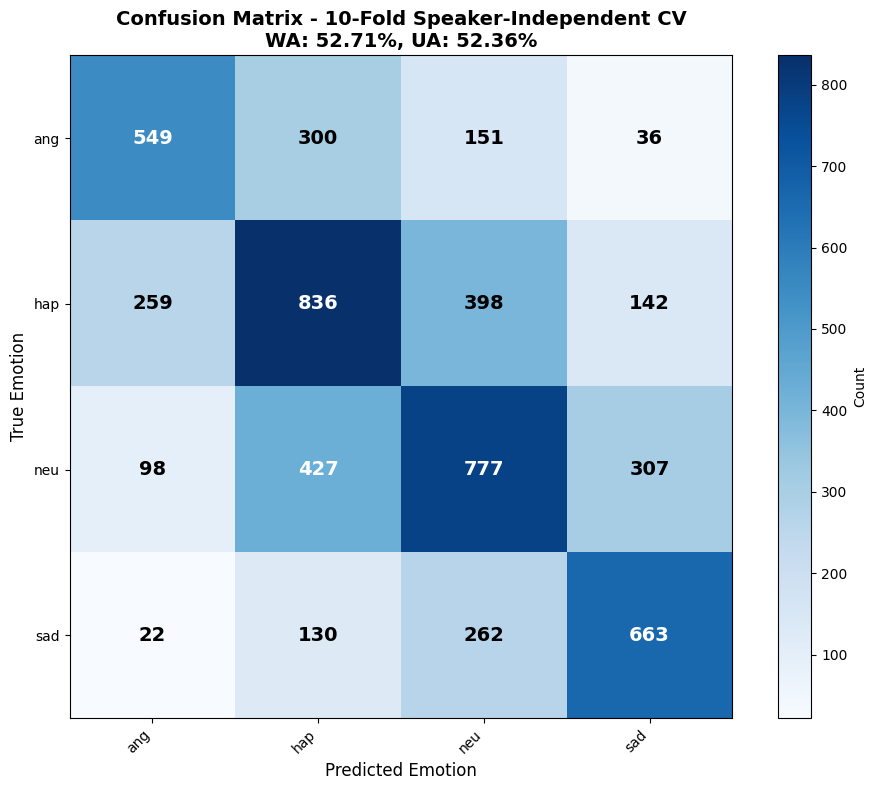


All results saved to: iemocap_results/
  - fold_results.csv
  - confusion_matrix_10fold.png
  - final_results.txt
  - label_encoder.pkl
  - best_model_fold*.pth (10 model checkpoints)

EXPERIMENT COMPLETED SUCCESSFULLY!

Final Performance (10-Fold Speaker-Independent CV):
  Weighted Accuracy (WA):   52.71%
  Unweighted Accuracy (UA): 52.36%


Compare with paper baselines (Table 2):
  Aftab et al. [4]:  WA=70.23%, UA=70.76%
  Feng et al. [8]:   WA=68.63%, UA=69.67%
  Zou et al. [10]:   WA=69.80%, UA=71.05%
  Your model:        WA=52.71%, UA=52.36%




In [16]:
# =============================================
# RUN THE EXPERIMENT
# =============================================

if __name__ == "__main__":
    mean_wa, mean_ua, results = run_speaker_independent_cv()
    
    print(f"\n{'='*70}")
    print("EXPERIMENT COMPLETED SUCCESSFULLY!")
    print(f"{'='*70}")
    print(f"\nFinal Performance (10-Fold Speaker-Independent CV):")
    print(f"  Weighted Accuracy (WA):   {mean_wa:.2f}%")
    print(f"  Unweighted Accuracy (UA): {mean_ua:.2f}%")
    print(f"\n{'='*70}")
    print("\nCompare with paper baselines (Table 2):")
    print("  Aftab et al. [4]:  WA=70.23%, UA=70.76%")
    print("  Feng et al. [8]:   WA=68.63%, UA=69.67%")
    print("  Zou et al. [10]:   WA=69.80%, UA=71.05%")
    print(f"  Your model:        WA={mean_wa:.2f}%, UA={mean_ua:.2f}%")
    print(f"\n{'='*70}\n")